# EDA: Premier League Player Transfer Value

Distribution of market value, market value vs. age, missingness, and correlation of value against performance stats.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_loader import build_dataset

sns.set_theme(style="whitegrid")

df = build_dataset()
df.shape

Matplotlib is building the font cache; this may take a moment.


(6295, 17)

In [2]:
df.head()

,player_id,season,market_value_eur,goals,assists,minutes_played,num_appearances,yellow_cards,red_cards,name,date_of_birth,position,sub_position,foot,height_in_cm,country_of_citizenship,age
0,132,2012,2000000,2,1,612,10,2,0,Tomas Rosicky,1980-10-04,Midfield,Attacking Midfield,both,179.0,Czech Republic,32.0
1,132,2013,2000000,2,1,1572,27,7,0,Tomas Rosicky,1980-10-04,Midfield,Attacking Midfield,both,179.0,Czech Republic,33.0
2,132,2014,2000000,2,1,576,15,1,0,Tomas Rosicky,1980-10-04,Midfield,Attacking Midfield,both,179.0,Czech Republic,34.0
3,488,2012,750000,0,0,1109,14,0,0,Gerhard Tremmel,1978-11-16,Goalkeeper,Goalkeeper,NaN,NaN,Germany,34.0
4,488,2013,1000000,0,0,1080,12,0,0,Gerhard Tremmel,1978-11-16,Goalkeeper,Goalkeeper,NaN,NaN,Germany,35.0


## Distribution of `market_value_eur`

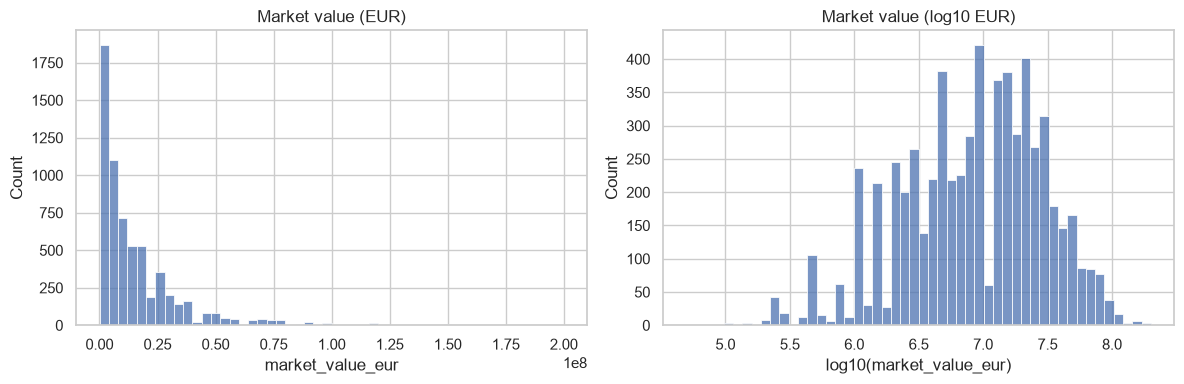

count    6.295000e+03
mean     1.595713e+07
std      1.905855e+07
min      5.000000e+04
25%      3.500000e+06
50%      1.000000e+07
75%      2.000000e+07
max      2.000000e+08
Name: market_value_eur, dtype: float64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["market_value_eur"], bins=50, ax=axes[0])
axes[0].set_title("Market value (EUR)")
axes[0].set_xlabel("market_value_eur")

sns.histplot(np.log10(df["market_value_eur"].replace(0, np.nan).dropna()), bins=50, ax=axes[1])
axes[1].set_title("Market value (log10 EUR)")
axes[1].set_xlabel("log10(market_value_eur)")

plt.tight_layout()
plt.show()

df["market_value_eur"].describe()

Market value is heavily right-skewed (a small number of high-value stars pull the raw distribution far to the right); the log scale looks close to log-normal, which is the usual reason to model `log(market_value_eur)` rather than the raw value.

## Market value vs. age

Expecting a non-linear relationship: value rising through a player's early 20s, peaking roughly around 24-27, then declining — not a straight line.

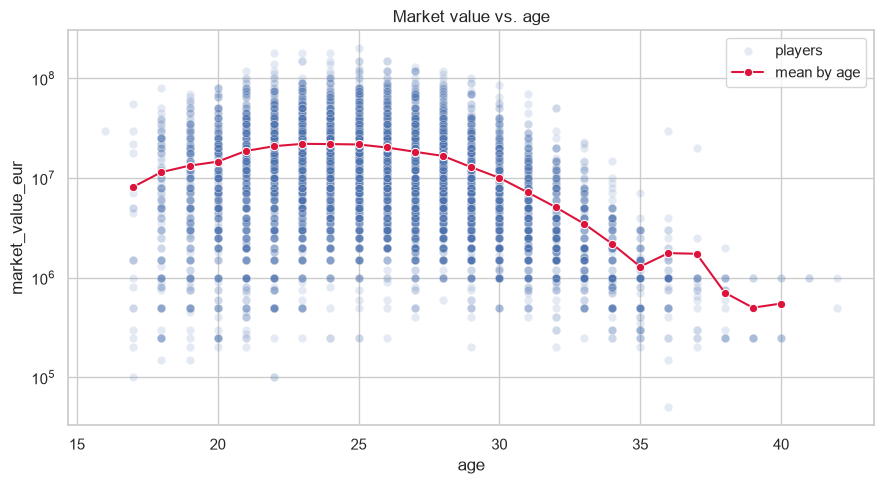

,age,mean,median,count
7,23.0,2.203443e+07,15000000.0,485
8,24.0,2.193346e+07,15000000.0,508
9,25.0,2.172213e+07,15000000.0,567
6,22.0,2.088243e+07,15000000.0,404
10,26.0,2.025977e+07,15000000.0,563
5,21.0,1.869231e+07,12000000.0,348
11,27.0,1.835208e+07,12000000.0,552
12,28.0,1.666590e+07,12000000.0,519
4,20.0,1.460996e+07,10000000.0,271
3,19.0,1.331564e+07,8000000.0,179


In [4]:
age_value = df.dropna(subset=["age", "market_value_eur"])
age_stats = age_value.groupby("age")["market_value_eur"].agg(["mean", "median", "count"]).reset_index()
age_stats = age_stats[age_stats["count"] >= 5]

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=age_value, x="age", y="market_value_eur", alpha=0.15, ax=ax, label="players")
sns.lineplot(data=age_stats, x="age", y="mean", color="crimson", marker="o", ax=ax, label="mean by age")
ax.set_yscale("log")
ax.set_title("Market value vs. age")
plt.tight_layout()
plt.show()

age_stats.sort_values("mean", ascending=False).head(10)

## Missingness report

In [5]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
missing

,n_missing,pct_missing
foot,35,0.56
height_in_cm,20,0.32
country_of_citizenship,18,0.29
age,4,0.06
date_of_birth,4,0.06
name,0,0.00
sub_position,0,0.00
position,0,0.00
player_id,0,0.00
season,0,0.00


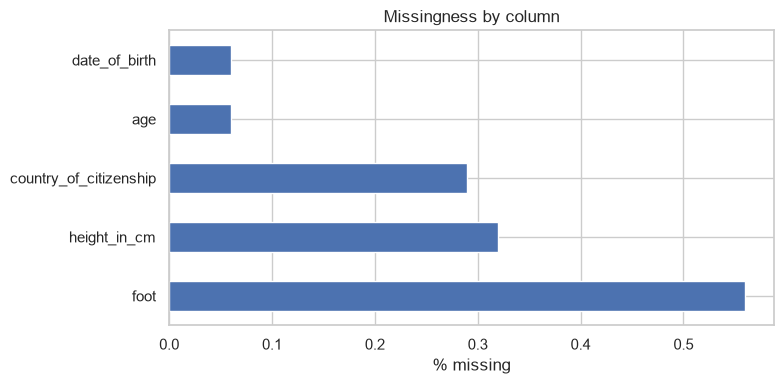

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
missing[missing["pct_missing"] > 0]["pct_missing"].plot.barh(ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Missingness by column")
plt.tight_layout()
plt.show()

## Correlation of value against performance stats

In [7]:
perf_cols = ["goals", "assists", "minutes_played", "num_appearances"]
corr = df[perf_cols + ["market_value_eur"]].corr()["market_value_eur"].drop("market_value_eur")
corr.sort_values(ascending=False)

goals              0.516130
assists            0.463770
num_appearances    0.382455
minutes_played     0.369830
Name: market_value_eur, dtype: float64

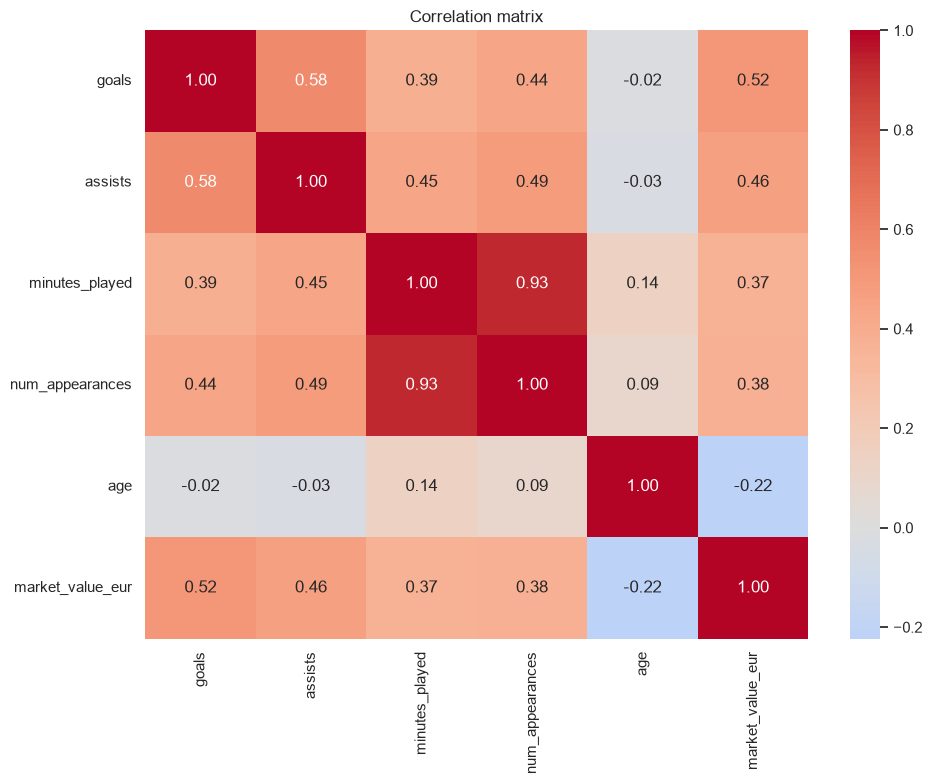

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[perf_cols + ["age", "market_value_eur"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()